# Presentation
This notebook produces the figure S3 of the corresponding article. This figure tests the sensitivity of observationnal methods to changes in the definition of the variables considered (X and Y).
- X, the observable variable used to constrain Y, is defined here either as a time-mean (on 2005-2023 for the AMOC and **1900**-2020 for the SST and SSS) or a time-trend (on 2005-2023 for the AMOC and **1975**-2020 for the SST and SSS).
- Y, the target variable to constrain, is defined here as a time-mean between 2091 and 2100, either in absolute or in relative to 1850-1900.

These 2x2 choices generates 4 different cases.

# Package importation

In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt

# Functions importation

In [2]:
sys.path.append('../functions/')
from OC_methods import performances_methods
from format_data import construct_data_given_scenario

# Fixed parameters

In [3]:
#------- Scenario choice
scenario = "ssp245"

#------- Y definition choice
# Y is the average on the period between min_Y and max_Y
# Its values can be anomalies, compared to the reference period between min_Y_ref and max_Y_ref
min_Y     = 2091
max_Y     = 2100
min_Y_ref = 1850
max_Y_ref = 1900

#------- Choose if you want to consider the past AMOC in the set of observable variables,
#------- in addition to the 18 observables variables (9 regions for 2 climate variables: the temperature and salinity)
include_AMOC_in_predictors=True

# Moving parameters: compute for each case of (X,Y) choices, the performances of the different observational constraint methods
**Warning !** This step takes a lot of time !


In [4]:
# Create storage for the results
X_simu_perChoice   = [] # The different multivariate X in each case
Y_simu_perChoice   = [] # The different Y in each case
models_perChoice   = []  # The climate models used in each case
poids_wA_perChoice = [] # The weights of the weighted average method in each case
X_simu_AMOC_perChoice   = [] # The different univariate X in each case
name_choice_perChoice   = [] # The name of the case in each case
list_list_LOO_perChoice = [] # The leave-one-out errors of methods in each case
list_list_predictions_perChoice = [] # The guesses of methods in each case
list_list_std_without_perChoice = [] # The standard deviation errors of methods in each case

#------ Detail each of the 4 cases
list_X_choice   = ["mean", "trend", "mean", "trend"]
max_X           = 2020
list_min_X      = [1900, 1975, 1900, 1975]
list_anomalie_Y = [False, False, True, True]
nb_choices      = len(list_X_choice)

#------ Compute the performances of each case
for id_choice in range(nb_choices):
    #----------- Get the parameters of the case
    X_choice   = list_X_choice[id_choice]
    min_X      = list_min_X[id_choice]
    anomalie_Y = list_anomalie_Y[id_choice]
    if anomalie_Y:
        name_Y_anom = "anomaly"
    else:
        name_Y_anom = "absolute"
    
    #----------- Construct data for X, Y choices
    [X_simu, Y_simu, Y_ref, X_simu_AMOC, X_AMOC_mean_1850_1900, final_name_models,
     X_obs, X_obs_AMOC, name_X_AMOC, name_Y
        ] = construct_data_given_scenario(scenario,
                           X_choice, anomalie_Y, min_Y, max_Y,
                           min_Y_ref, max_Y_ref, min_X, max_X,
                           include_AMOC_in_predictors)

    #----------- Store the data
    X_simu_AMOC_perChoice.append(X_simu_AMOC)
    X_simu_perChoice.append(X_simu)
    Y_simu_perChoice.append(Y_simu)
    models_perChoice.append(final_name_models)
    
    #----------- Compute performances
    [name_methods, list_list_predictions, list_list_std_without, list_list_LOO, poids_wA
            ] = performances_methods(X_simu_AMOC, X_obs_AMOC, X_simu, X_obs, Y_simu)

    #----------- Store the performances
    poids_wA_perChoice.append(poids_wA)
    name_choice_perChoice.append("X: time {}s\nY: {}".format(X_choice, name_Y_anom))
    list_list_LOO_perChoice.append(list_list_LOO)
    list_list_predictions_perChoice.append(list_list_predictions)
    list_list_std_without_perChoice.append(list_list_std_without)


C:\Users\vportmann\.conda\envs\venvArticle2\lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\vportmann\.conda\envs\venvArticle2\lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\vportmann\Desktop\ComparisonAmocConstraints\notebooks\../functions\format_data.py:102: RuntimeWarning: Mean of empty slice
  Y_simu_anom = np.nanmean(Y_anom[:, times_to_mean], axis=1)
C:\Users\vportmann\Desktop\ComparisonAmocConstraints\notebooks\../functions\format_data.py:108: RuntimeWarning: Mean of empty slice
  Y_simu = np.nanmean(Y[:, times_to_mean], axis=1)


MMM

wAverage

LR

Ridge

RF

MMM

wAverage

LR

Ridge

RF



C:\Users\vportmann\.conda\envs\venvArticle2\lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\vportmann\.conda\envs\venvArticle2\lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\vportmann\Desktop\ComparisonAmocConstraints\notebooks\../functions\format_data.py:102: RuntimeWarning: Mean of empty slice
  Y_simu_anom = np.nanmean(Y_anom[:, times_to_mean], axis=1)
C:\Users\vportmann\Desktop\ComparisonAmocConstraints\notebooks\../functions\format_data.py:108: RuntimeWarning: Mean of empty slice
  Y_simu = np.nanmean(Y[:, times_to_mean], axis=1)


MMM

wAverage

LR

Ridge

RF

MMM

wAverage

LR

Ridge

RF



C:\Users\vportmann\.conda\envs\venvArticle2\lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\vportmann\.conda\envs\venvArticle2\lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\vportmann\Desktop\ComparisonAmocConstraints\notebooks\../functions\format_data.py:102: RuntimeWarning: Mean of empty slice
  Y_simu_anom = np.nanmean(Y_anom[:, times_to_mean], axis=1)


MMM

wAverage

LR

Ridge

RF

MMM

wAverage

LR

Ridge

RF



C:\Users\vportmann\.conda\envs\venvArticle2\lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\vportmann\.conda\envs\venvArticle2\lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\vportmann\Desktop\ComparisonAmocConstraints\notebooks\../functions\format_data.py:102: RuntimeWarning: Mean of empty slice
  Y_simu_anom = np.nanmean(Y_anom[:, times_to_mean], axis=1)


MMM

wAverage

LR

Ridge

RF

MMM

wAverage

LR

Ridge

RF



# Create the function that plot the performances for one case

In [7]:
def cross_validation_plot(ax, bbox_to_anchor):
    #------- Display parameters
    x = 0.18
    alpha = 0.6
    beta = x
    xmin = 0
    #------- Plot the performance method by method
    for id_method in range(nb_methods):
        # For each method, the performance is given when X is univariate or multivariate
        for i in range(2):
            # The shift separate the cases when X is rather univariate or multivariate
            if id_method==0: shift = 0
            else: shift = beta*(2*i-1)
            # Get the corresponding leave-one-out error
            LOO_err = list_list_LOO_perChoice[id_choice][i][id_method]

            # The univariate case in displayed in solid, while the multivariate in dashed
            if id_method!=0:
                if i==0:
                    linestyle="solid"
                    ax.fill_between(id_method+shift+np.array([-x,x]), y1=[xmin,xmin], y2=LOO_err*np.array([1,1]), color=colors[id_method], alpha=alpha)
                else:
                    linestyle="dashed"
                    ax.fill_between(id_method+shift+np.array([-x,x]), y1=[xmin,xmin], y2=LOO_err*np.array([1,1]),
                                         color="none", hatch="XXX", edgecolor=colors[id_method])

            else:
                line0 = ax.fill_between(id_method+shift+np.array([-x,x]), y1=[xmin,xmin], y2=LOO_err*np.array([1,1]),
                                     facecolors='none', edgecolors=colors[id_method], linewidth=2)

    #------- The name of the methods are displayed only for the last row, to optimise the rendering
    if (id_choice>=3-1):
        ax.set_xticks(range(nb_methods))
        ax.set_xticklabels(name_methods, fontsize=20, rotation=60, ha='right', va='top')
        ax.get_xticklabels()[3].set_fontweight("bold")
    else:
        ax.set_xticks([])
        
    #------- Add a grid and a legend
    ax.grid(axis="y")
    plt.rc('axes', axisbelow=True)
    line1 = ax.fill_between(id_method+np.array([-x,x])+10, y1=[xmin,xmin], y2=LOO_err*np.array([1,1]),
                                 color="gray", alpha=alpha, label="one predictor")
    line2 = ax.fill_between(id_method+np.array([-x,x])+10, y1=[xmin,xmin], y2=LOO_err*np.array([1,1]),
                                 color="none", hatch="XXX", edgecolor="gray", label="multiple predictor")
    leg = fig.legend([line1, line2, line0],
               ["one observed variable", "multiple observed variables", "Unconstrained"], #"1 "+r"$\sigma$"+" interval"],
               title="Constrained by", loc='center left', bbox_to_anchor=bbox_to_anchor, fontsize=16)
    plt.rcParams['legend.title_fontsize'] = 16
    leg._legend_box.align = "left"

    #------- Set the limits of the plot
    ax.set_ylim(0, max_*1.05)
    ax.set_xlim(-0.5, nb_methods-0.5)
    ax.tick_params(labelsize=20) 

# Display the performances for all cases (figure S3)

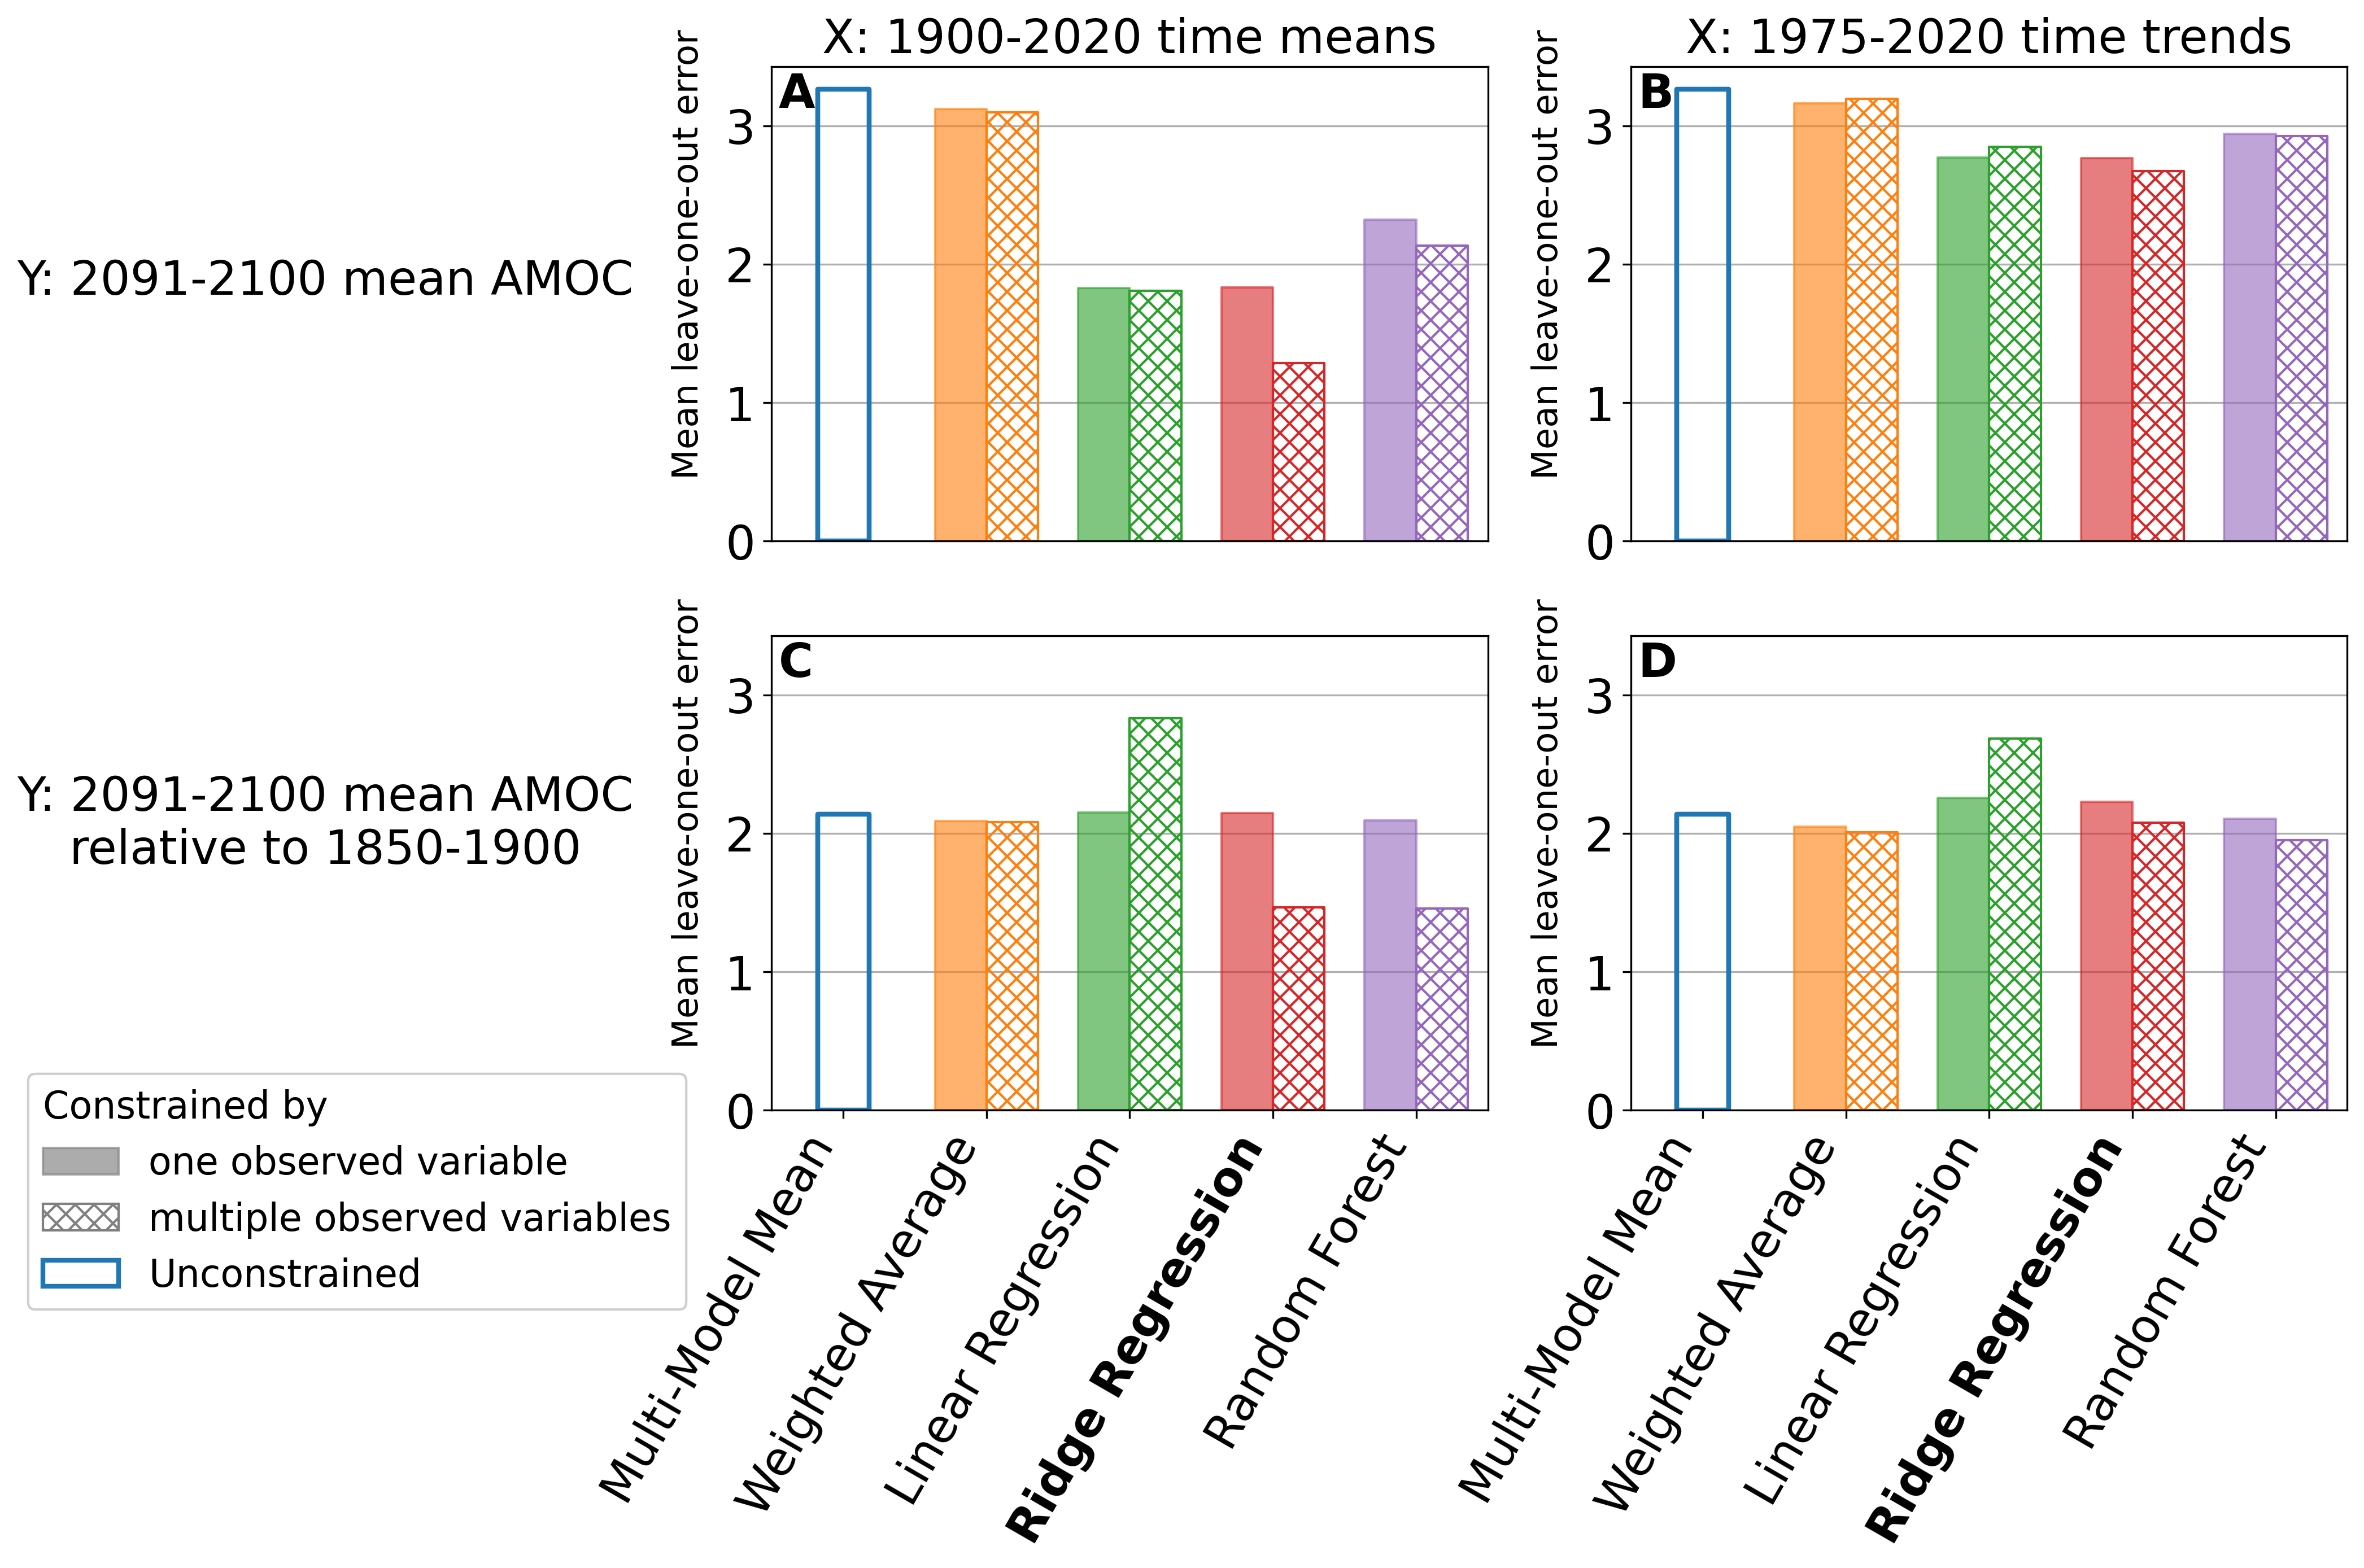

In [8]:
#------- Get the parameters and initialise the figure
nb_methods   = len(list_list_LOO_perChoice[0][0])
max_         = np.max(list_list_LOO_perChoice)
fig, axes    = plt.subplots(2,2, dpi=300, figsize=(6*2,8))
prop_cycle   = plt.rcParams['axes.prop_cycle']
colors       = prop_cycle.by_key()['color']
name_methods = ["Multi-Model Mean", "Weighted Average", "Linear Regression", "Ridge Regression", "Random Forest"]

#------- Display the performances case after case
for id_choice in range(nb_choices):
    # Get the values of the parameters, choices, and performances
    name_choice = name_choice_perChoice[id_choice]
    X_simu_AMOC = X_simu_AMOC_perChoice[id_choice]
    X_simu      = X_simu_perChoice[id_choice]
    Y_simu      = Y_simu_perChoice[id_choice]
    name_models = models_perChoice[id_choice]
    list_list_std_without = list_list_std_without_perChoice[id_choice]
    list_list_predictions = list_list_predictions_perChoice[id_choice]

    # Display cross-validation errors
    cross_validation_plot(axes.flatten()[id_choice], bbox_to_anchor=(-0.25, 0.05))

#------- Display the names of the (X,Y) choices for each cases, corresponding to each row and column
for ax, col in zip(axes.flatten(), ["X: 1900-2020 time means", "X: 1975-2020 time trends"]):
    ax.set_title(col, rotation=0, fontsize=20)
for ax, row in zip(axes[:,0], ["Y: 2091-2100 mean AMOC", "Y: 2091-2100 mean AMOC\nrelative to 1850-1900"]):
    ax.set_ylabel(row, rotation=0, fontsize=20, labelpad=170)

#------- Index the subplots and add a label for the y-axis
list_letters = ["A", "B", "C", "D"]
i = 0
for ax in axes.flatten():
    ax.text(-1.2, 0.5, "Mean leave-one-out error", rotation=90, fontsize=15)
    ax.text(.01, .99, list_letters[i], ha='left', va='top', fontsize=20, transform=ax.transAxes, weight='bold')
    i += 1
    
plt.show()

